In [1]:
import torch
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

from SuperpixelOcclusion import SuperpixelOcclusion

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights).to(device)
model.eval()

categories = weights.meta["categories"]

In [2]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA available: True
CUDA version: 12.1
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
torch.__version__

'2.5.1+cu121'

In [4]:
# Create explainer
explainer = SuperpixelOcclusion(model, device=device)

# Superpixel parameters (tradeoff: more segments -> finer map but slower)
n_segments = 200
compactness = 10.0
sigma = 1.0

# Occlusion parameters
occlusion_value = "mean"   # recommended for ImageNet-normalized inputs
mode = "prob_drop"         # "prob_drop" or "logit_drop"
batch_size = 32


In [5]:
preprocess = weights.transforms()

def load_image(path):
    img = Image.open(path).convert("RGB")
    tensor = preprocess(img).unsqueeze(0)
    return img, tensor

In [6]:
img, input_tensor = load_image("../Pictures/Indian_Cobra.jpg")
input_tensor = input_tensor.to(device)

# Single source of truth for target + confidence
with torch.no_grad():
    logits = model(input_tensor)
    probs = torch.softmax(logits, dim=1)

target_idx = int(torch.argmax(probs, dim=1).item())
confidence = float(probs[0, target_idx].item())
label = categories[target_idx]

_, _, H, W = input_tensor.shape
segmentation_image = np.array(img.resize((W, H)))  # rovnako ako v spoločnom notebooku

sp_map, _, segment_drops, segments = explainer.explain(
    input_tensor,
    target_class=target_idx,
    segmentation_image=segmentation_image,
    segmentation="slic",
    n_segments=n_segments,
    compactness=compactness,
    sigma=sigma,
    occlusion_value=occlusion_value,
    mode=mode,
    batch_size=batch_size,
    keep_negative=False,
)

print(f"Predicted class: {label}")
print(f"Confidence: {confidence:.4f}")
print("Unique segments:", int(segments.max()) + 1)

Predicted class: Indian cobra
Confidence: 0.3244
Unique segments: 180


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def denormalize_for_display(t, weights):
    mean = torch.tensor(weights.transforms().mean).view(1,3,1,1).to(t.device)
    std = torch.tensor(weights.transforms().std).view(1,3,1,1).to(t.device)
    x = (t * std) + mean
    x = x.clamp(0, 1)
    x = (x[0].permute(1,2,0).detach().cpu().numpy() * 255).astype(np.uint8)
    return x

def overlay(img_uint8, hm, alpha=0.45):
    hm_rgba = plt.get_cmap("jet")(hm)
    hm_rgb = (hm_rgba[..., :3] * 255).astype(np.uint8)
    return (img_uint8 * (1 - alpha) + hm_rgb * alpha).astype(np.uint8)

img_disp = denormalize_for_display(input_tensor, weights)

# comparable map
sp_hm = sp_map[0,0].detach().cpu().numpy()

# comparable overlay
sp_overlay_raw = overlay(img_disp, sp_hm, alpha=0.45)

# legacy enhanced overlay
sp_hm_legacy = np.power(sp_hm, 0.7)
sp_overlay_legacy = overlay(img_disp, sp_hm_legacy, alpha=0.5)


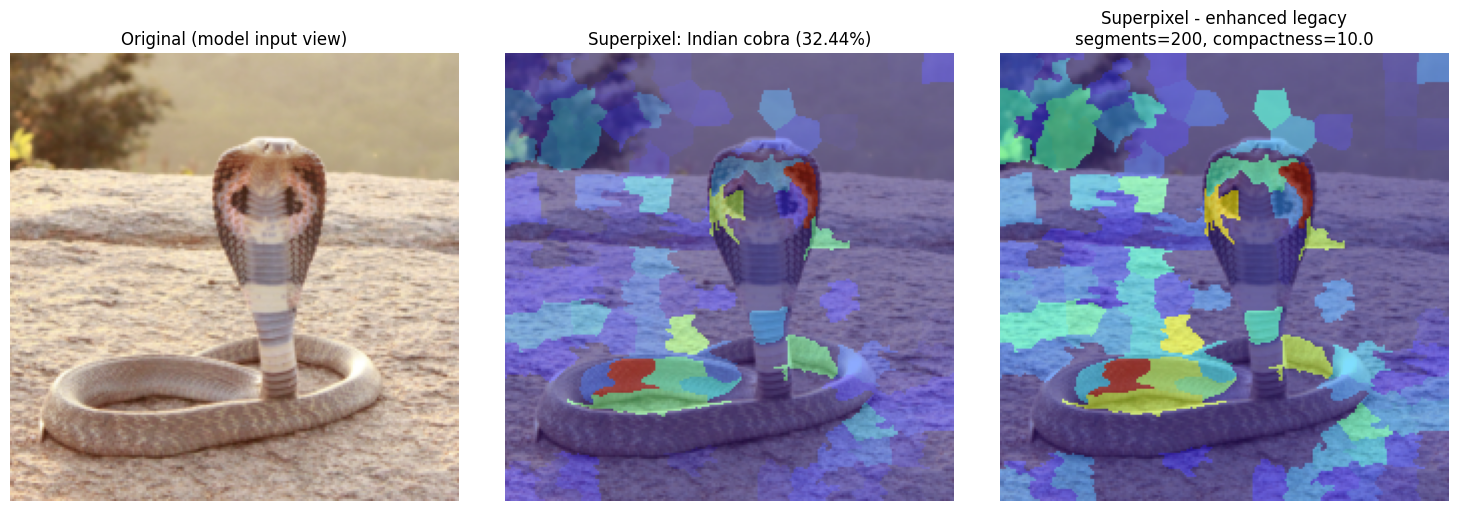

In [9]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_disp)
plt.title("Original (model input view)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sp_overlay_raw)
plt.title(f"Superpixel: {label} ({confidence:.2%})")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sp_overlay_legacy)
plt.title(f"Superpixel - enhanced legacy\nsegments={n_segments}, compactness={compactness}")
plt.axis("off")

plt.tight_layout()
plt.show()


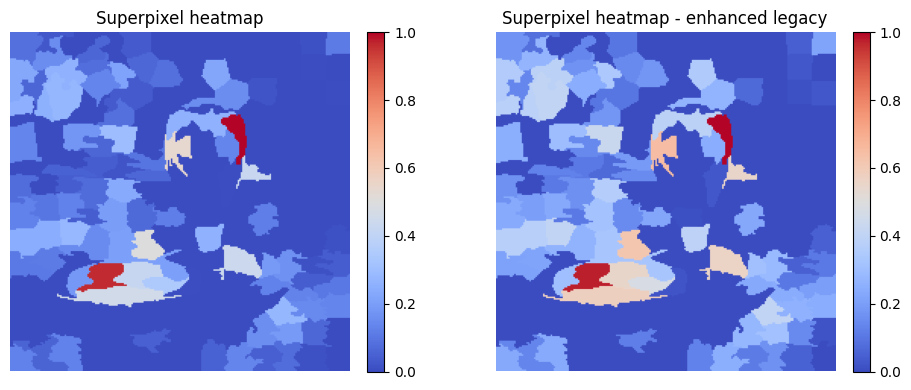

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sp_hm, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Superpixel heatmap")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,2,2)
plt.imshow(sp_hm_legacy, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Superpixel heatmap - enhanced legacy")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()